In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io as sio
import scipy.optimize as opt
import scipy.signal as sig
from scipy.integrate import trapezoid

{'Tstart': array([[0.]]), 'Tinterval': array([[9.99999997e-07]]), 'ExtraSamples': array([[0]], dtype=int32), 'RequestedLength': array([[10000000]], dtype=int32), 'Length': array([[10000000]], dtype=int32), 'D': array([[0.03204737],
       [0.03442803],
       [0.03204737],
       ...,
       [0.        ],
       [0.        ],
       [0.        ]], shape=(10000000, 1), dtype=float32), 'Version': array(['6', '.', '1', '4', '.', '6', '9', '.', '6', '4', '0', '1'],
      dtype='<U1')}


C:\Users\yuhan\AppData\Local\Temp\ipykernel_70380\1379392944.py:11: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  ff, Pxx = sig.welch(data['D'][:, 0], fs=1/float(data['Tinterval']), nperseg=2**19)


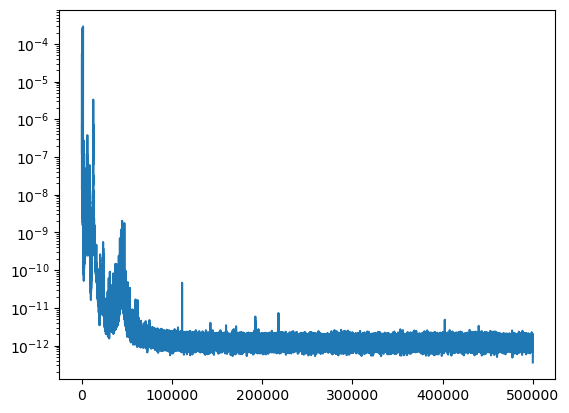

In [15]:
name = '20260423_derivative-UGF-49p3kHz_4th-order-15kHz-293kHz_20dB'

filename = f'D:/electric_feedback/sphere_20260422/{name}.mat'
data = sio.loadmat(filename)

print(data)

# time_array = np.linspace(0, 10, file['Length'][0])
# z_array = file['D'][:, 0]

ff, Pxx = sig.welch(data['D'][:, 0], fs=1/float(data['Tinterval']), nperseg=2**19)

plt.semilogy(ff, Pxx)

C:\Users\yuhan\AppData\Local\Temp\ipykernel_74828\323870635.py:15: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  ff, Pxx = sig.welch(data[chans[i]][:, 0], fs=1/float(data['Tinterval']), nperseg=2**19)


Text(0, 0.5, 'PSD [V$^2$/Hz]')

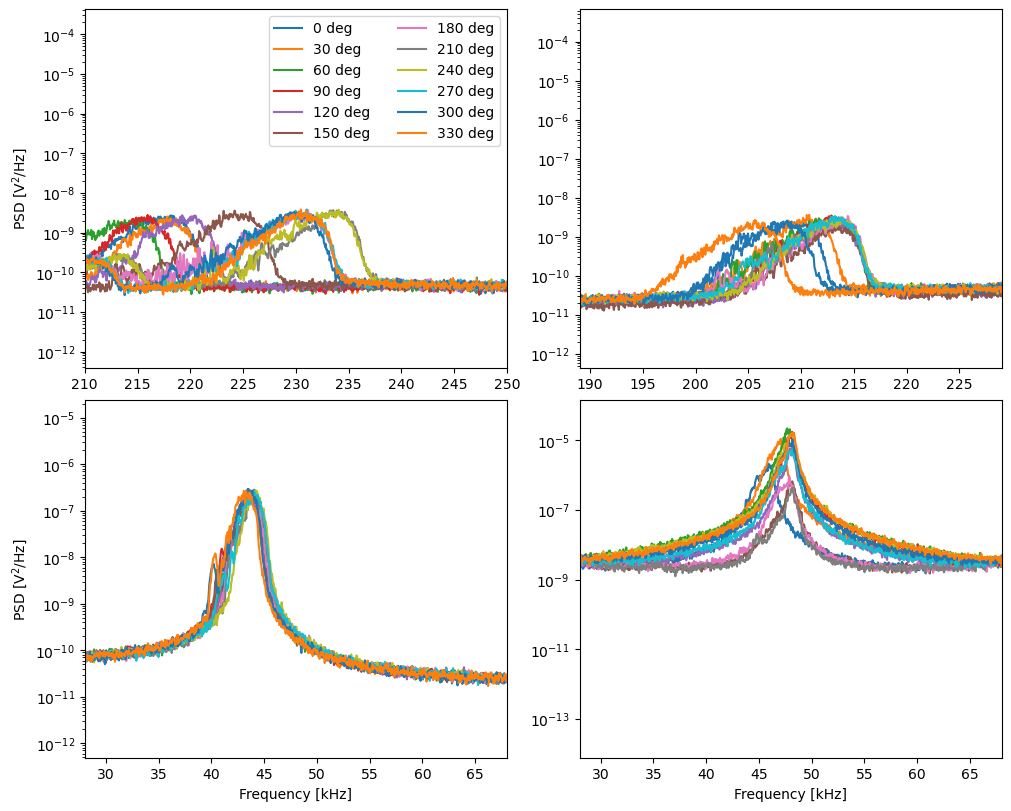

: 

In [ ]:
phases = np.arange(0, 340, 30)

axes = ['x', 'y', 'zf', 'zb']
chans = ['A', 'B', 'C', 'D']
res_freqs = np.array([230, 209, 48, 48])*1e3

areas = np.zeros((len(axes), len(phases)))

fig, ax = plt.subplots(2, 2, figsize=(10, 8), layout='constrained')

for i, axis in enumerate(axes):
    for j, phase in enumerate(phases):
        filename = f'D:/cooling/20260123_pll_tuning_5e-2mbar/{axis}_{phase}.mat'
        data = sio.loadmat(filename)
        ff, Pxx = sig.welch(data[chans[i]][:, 0], fs=1/float(data['Tinterval']), nperseg=2**19)
        freq_band = res_freqs[i] + np.array((-2e4, 2e4))
        ind1 = np.argmin(np.abs(ff - freq_band[0]))
        ind2 = np.argmin(np.abs(ff - freq_band[1]))
        area = trapezoid(Pxx[ind1:ind2], ff[ind1:ind2])
        areas[i, j] = trapezoid(Pxx[ind1:ind2], ff[ind1:ind2])
        ax[i // 2, i % 2].semilogy(ff*1e-3, Pxx, label=f'{phase} deg')
        ax[i // 2, i % 2].set_xlim(freq_band*1e-3)

ax[0, 0].legend(ncol=2)
ax[1, 0].set_xlabel('Frequency [kHz]')
ax[1, 1].set_xlabel('Frequency [kHz]')
ax[0, 0].set_ylabel('PSD [V$^2$/Hz]')
ax[1, 0].set_ylabel('PSD [V$^2$/Hz]')


[np.int64(60), np.int64(150), np.int64(180), np.int64(210)]


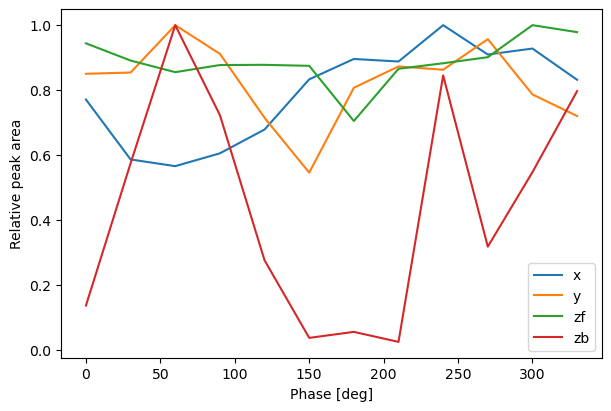

In [83]:
min_phases = []

fig, ax = plt.subplots(figsize=(6, 4), layout='constrained')

for i, axis in enumerate(axes):
    ax.plot(phases, areas[i, :]/np.amax(areas[i, :]), label=axis)
    min_phases.append(phases[np.argmin(areas[i, :])])

ax.legend()
ax.set_xlabel('Phase [deg]')
ax.set_ylabel('Relative peak area')

print(min_phases)

C:\Users\yuhan\AppData\Local\Temp\ipykernel_74828\2905974257.py:15: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  ff, Pxx = sig.welch(data[chans[i]][:, 0], fs=1/float(data['Tinterval']), nperseg=2**17)


Text(0, 0.5, 'PSD [V$^2$/Hz]')

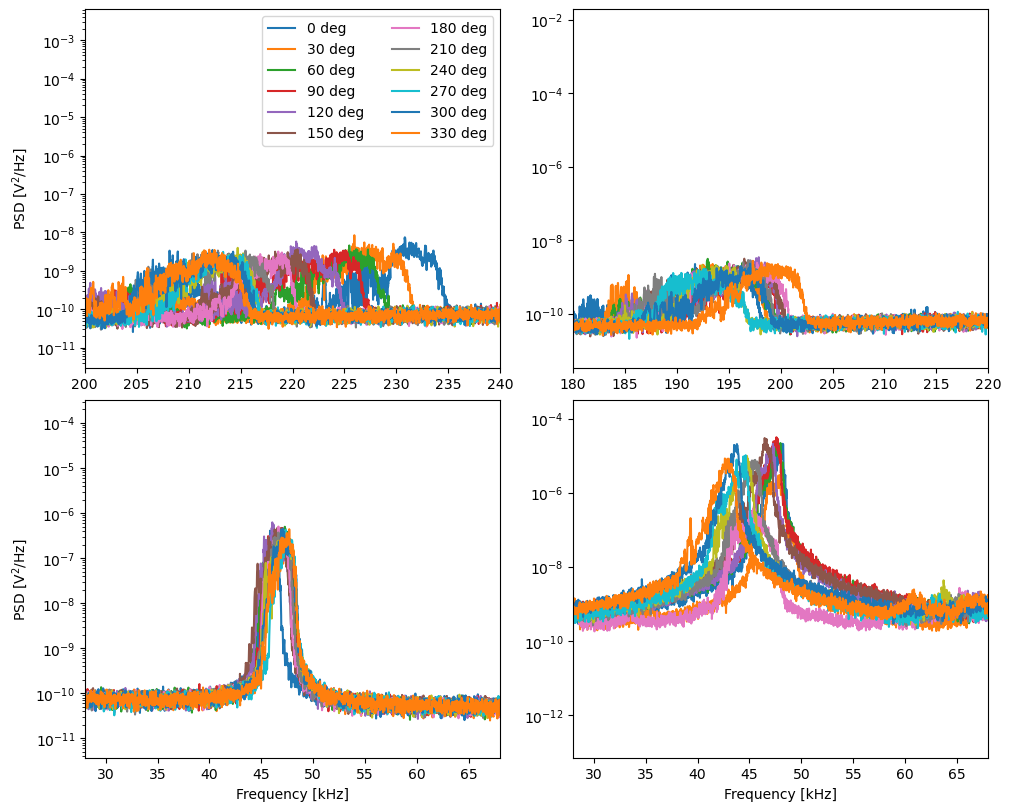

In [88]:
phases = np.arange(0, 340, 30)

axes = ['x', 'y', 'zf', 'zb']
chans = ['A', 'B', 'C', 'D']
res_freqs = np.array([220, 200, 48, 48])*1e3

areas = np.zeros((len(axes), len(phases)))

fig, ax = plt.subplots(2, 2, figsize=(10, 8), layout='constrained')

for i, axis in enumerate(axes):
    for j, phase in enumerate(phases):
        filename = f'D:/cooling/20260123_pll_tuning_7e-3mbar/{axis}_{phase}.mat'
        data = sio.loadmat(filename)
        ff, Pxx = sig.welch(data[chans[i]][:, 0], fs=1/float(data['Tinterval']), nperseg=2**17)
        freq_band = res_freqs[i] + np.array((-2e4, 2e4))
        ind1 = np.argmin(np.abs(ff - freq_band[0]))
        ind2 = np.argmin(np.abs(ff - freq_band[1]))
        area = trapezoid(Pxx[ind1:ind2], ff[ind1:ind2])
        areas[i, j] = trapezoid(Pxx[ind1:ind2], ff[ind1:ind2])
        ax[i // 2, i % 2].semilogy(ff*1e-3, Pxx, label=f'{phase} deg')
        ax[i // 2, i % 2].set_xlim(freq_band*1e-3)

ax[0, 0].legend(ncol=2)
ax[1, 0].set_xlabel('Frequency [kHz]')
ax[1, 1].set_xlabel('Frequency [kHz]')
ax[0, 0].set_ylabel('PSD [V$^2$/Hz]')
ax[1, 0].set_ylabel('PSD [V$^2$/Hz]')


[np.int64(180), np.int64(270), np.int64(30), np.int64(180)]


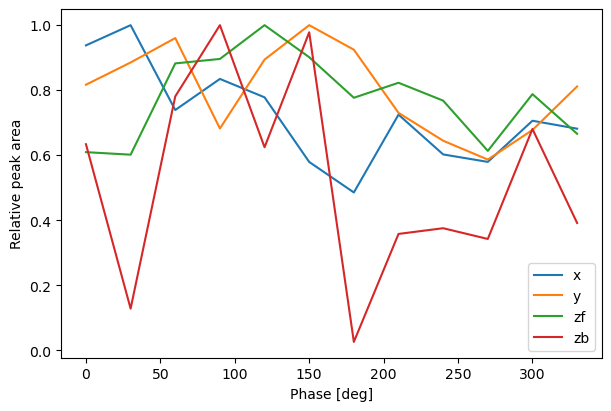

In [89]:
min_phases = []

fig, ax = plt.subplots(figsize=(6, 4), layout='constrained')

for i, axis in enumerate(axes):
    ax.plot(phases, areas[i, :]/np.amax(areas[i, :]), label=axis)
    min_phases.append(phases[np.argmin(areas[i, :])])

ax.legend()
ax.set_xlabel('Phase [deg]')
ax.set_ylabel('Relative peak area')

print(min_phases)